<a href="https://colab.research.google.com/github/MiguelMoli/Miguel-Kevin-Felipe/blob/main/FormulasFisicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Posicion con velocidad constante

x=xo+vt

x = posición final (m)

xo = posición inicial (m)

v = velocidad (m/s)

t = tiempo (s)

Un tren parte desde la posición 50 my avanza a 20 m/s durante 5 s. ¿Cuál es su posición final?

## Velocidad con aceleracion constante

v=Vo+at

v = velocidad final (m/s)

Vo = velocidad inicial (m/s)

a= aceleración (m/s²)

t=tiempo (s)

Un automóvil inicia con velocidad de 5 m/sy acelera a 2 m/s² durante 4 s. ¿Cuál es su velocidad final?

In [3]:
import numpy as np
from scipy.optimize import fsolve


def resolver_posicion(x=None, x0=None, v=None, t=None):

    variables = {"x": x, "x0": x0, "v": v, "t": t}

    faltante = None
    for clave, valor in variables.items():
        if valor is None:
            faltante = clave
            break

    unidades = {"x": "m", "x0": "m", "v": "m/s", "t": "s"}

    if variables["t"] == 0:
        if faltante == "v":
            print("Error: No se puede calcular v si t = 0")
            return "repetir_t"
        if faltante == "x":
            print(f"\nResultado: x = {variables['x0']} m")
            return "ok"
        if faltante == "x0":
            print(f"\nResultado: x0 = {variables['x']} m")
            return "ok"

    def ecuacion(var):
        valores = variables.copy()
        valores[faltante] = var[0]
        return valores["x0"] + valores["v"] * valores["t"] - valores["x"]

    solucion = fsolve(ecuacion, 1)
    print(f"\nResultado: {faltante} = {solucion[0]} {unidades[faltante]}")
    return "ok"


def resolver_velocidad(v=None, v0=None, a=None, t=None):

    variables = {"v": v, "v0": v0, "a": a, "t": t}

    faltante = None
    for clave, valor in variables.items():
        if valor is None:
            faltante = clave
            break

    unidades = {"v": "m/s", "v0": "m/s", "a": "m/s2", "t": "s"}

    if variables["t"] == 0:

        if faltante == "a":
            if variables["v"] != variables["v0"]:
                print("Error: No hay solución (v ≠ v0 cuando t = 0)")
            else:
                print("Infinitas soluciones: cualquier 'a' funciona (t = 0)")
            return "repetir_t"

        if faltante == "v":
            print(f"\nResultado: v = {variables['v0']} m/s")
            return "ok"

        if faltante == "v0":
            print(f"\nResultado: v0 = {variables['v']} m/s")
            return "ok"

    def ecuacion(var):
        valores = variables.copy()
        valores[faltante] = var[0]
        return valores["v0"] + valores["a"] * valores["t"] - valores["v"]

    solucion = fsolve(ecuacion, 1)
    print(f"\nResultado: {faltante} = {solucion[0]} {unidades[faltante]}")
    return "ok"


def pedir_opcion():
    while True:
        opcion = input(
            "\n¿Qué fórmula deseas usar?\n"
            "(P) Posición (x = x0 + v*t)\n"
            "(V) Velocidad (v = v0 + a*t)\n"
        ).lower()

        if opcion in ["p", "v"]:
            return opcion
        else:
            print("Error: Debes escribir 'P' o 'V'")


def pedir_incognita(opcion):
    if opcion == "p":
        validas = ["x", "x0", "v", "t"]
    else:
        validas = ["v", "v0", "a", "t"]

    while True:
        inc = input(f"¿Cuál es la incógnita? {validas}: ").lower()
        if inc in validas:
            return inc
        else:
            print("Error: Incógnita inválida")


def pedir_valor(nombre):
    while True:
        valor = input(f"Ingrese el valor de {nombre}: ")
        try:
            valor = float(valor)

            if nombre == "t" and valor < 0:
                print("Error: El tiempo no puede ser negativo")
                continue

            return valor

        except:
            print("Error: Debe ser un número válido")


while True:

    opcion = pedir_opcion()
    incognita = pedir_incognita(opcion)

    if opcion == "p":
        variables = ["x", "x0", "v", "t"]
    else:
        variables = ["v", "v0", "a", "t"]

    datos = {}

    for var in variables:
        if var == incognita:
            datos[var] = None
        else:
            datos[var] = pedir_valor(var)

    while True:
        if opcion == "p":
            resultado = resolver_posicion(**datos)
        else:
            resultado = resolver_velocidad(**datos)

        if resultado == "ok":
            break
        elif resultado == "repetir_t":
            datos["t"] = pedir_valor("t")

    while True:
        repetir = input("\n¿Deseas hacer otro cálculo? (s/n): ").lower()
        if repetir in ["s", "n"]:
            break
        else:
            print("Error: escribe 's' o 'n'")

    if repetir == "n":
        print("Programa finalizado")
        break


¿Qué fórmula deseas usar?
(P) Posición (x = x0 + v*t)
(V) Velocidad (v = v0 + a*t)
p
¿Cuál es la incógnita? ['x', 'x0', 'v', 't']: x
Ingrese el valor de x0: 123
Ingrese el valor de v: 23
Ingrese el valor de t: 32

Resultado: x = 859.0 m

¿Deseas hacer otro cálculo? (s/n): n
Programa finalizado


1. Para las formulas asignadas a cada grupo, identificar y describir las variables que intervienen.

a. Posición Final ($x$) vs. Tiempo ($t$)Relación: Directamente proporcional.¿Por qué?: A mayor tiempo transcurrido, mayor es la distancia recorrida. Si el tiempo aumenta al doble, el incremento de posición respecto al origen también se duplica.

b. Posición Final ($x$) vs. Velocidad ($v$)Relación: Directamente proporcional.¿Por qué?: Si mantienes el tiempo constante pero aumentas la velocidad, llegarás más lejos. La relación es lineal y positiva.

c. Posición Final ($x$) vs. Posición Inicial ($x_0$)Relación: Directa.¿Por qué?: El punto de llegada depende directamente de dónde empezaste. Si empiezas 10 metros más adelante, terminarás 10 metros más adelante del resultado original.

d. Velocidad ($v$) vs. Tiempo ($t$)Relación: Inversamente proporcional (para una distancia fija).¿Por qué?: Si quieres llegar a una posición final ($x$) específica desde un punto $x_0$, mientras más rápido vayas ($v$), menos tiempo ($t$) necesitarás. Si duplicas la velocidad, tardas la mitad del tiempo.ShutterstockExplorar

e. Velocidad ($v$) vs. Desplazamiento ($x - x_0$)Relación: Directamente proporcional.¿Por qué?: Para cubrir una distancia mayor en el mismo tiempo, obligatoriamente debes aumentar la velocidad.

f. Tiempo ($t$) vs. Desplazamiento ($x - x_0$)Relación: Directamente proporcional.¿Por qué?: Si la velocidad es constante, para recorrer una distancia más larga (un desplazamiento mayor), el reloj debe marcar más tiempo.


¿Qué fórmula deseas usar?
(P) Posición (x = x0 + v*t)
(V) Velocidad (v = v0 + a*t)
p
¿Cuál es la incógnita? ['x', 'x0', 'v', 't']: v
Ingrese el valor de x: 45
Ingrese el valor de x0: 22
Ingrese el valor de t: 21

Resultado: v = 1.0952380952380953 m/s


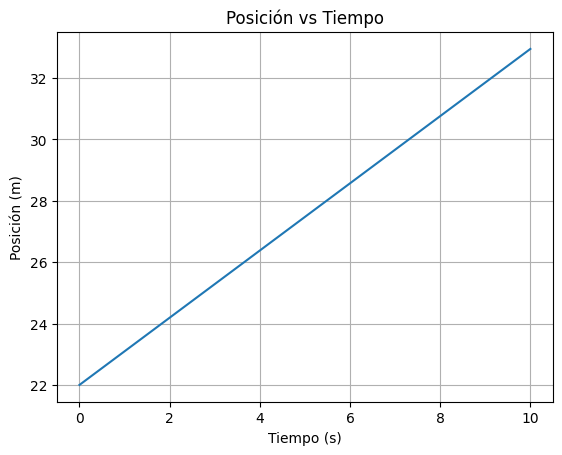

KeyboardInterrupt: Interrupted by user

In [2]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt


# ================== FUNCIONES DE GRÁFICA ==================

def graficar_posicion(x0, v, t_max=10):
    t = np.linspace(0, t_max, 100)
    x = x0 + v * t

    plt.plot(t, x)
    plt.title("Posición vs Tiempo")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Posición (m)")
    plt.grid()
    plt.show()


def graficar_velocidad(v0, a, t_max=10):
    t = np.linspace(0, t_max, 100)
    v = v0 + a * t

    plt.plot(t, v, color="red")
    plt.title("Velocidad vs Tiempo")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Velocidad (m/s)")
    plt.grid()
    plt.show()


# ================== FUNCIONES DE CÁLCULO ==================

def resolver_posicion(x=None, x0=None, v=None, t=None):

    variables = {"x": x, "x0": x0, "v": v, "t": t}

    faltante = None
    for clave, valor in variables.items():
        if valor is None:
            faltante = clave
            break

    unidades = {"x": "m", "x0": "m", "v": "m/s", "t": "s"}

    if variables["t"] == 0:
        if faltante == "v":
            print("Error: No se puede calcular v si t = 0")
            return "repetir_t"
        if faltante == "x":
            print(f"\nResultado: x = {variables['x0']} m")
            graficar_posicion(variables["x0"], variables["v"])
            return "ok"
        if faltante == "x0":
            print(f"\nResultado: x0 = {variables['x']} m")
            graficar_posicion(variables["x"], variables["v"])
            return "ok"

    def ecuacion(var):
        valores = variables.copy()
        valores[faltante] = var[0]
        return valores["x0"] + valores["v"] * valores["t"] - valores["x"]

    solucion = fsolve(ecuacion, 1)
    resultado = solucion[0]

    print(f"\nResultado: {faltante} = {resultado} {unidades[faltante]}")

    # Completar valores y graficar
    valores = variables.copy()
    valores[faltante] = resultado

    if valores["x0"] is not None and valores["v"] is not None:
        graficar_posicion(valores["x0"], valores["v"])

    return "ok"


def resolver_velocidad(v=None, v0=None, a=None, t=None):

    variables = {"v": v, "v0": v0, "a": a, "t": t}

    faltante = None
    for clave, valor in variables.items():
        if valor is None:
            faltante = clave
            break

    unidades = {"v": "m/s", "v0": "m/s", "a": "m/s2", "t": "s"}

    if variables["t"] == 0:

        if faltante == "a":
            if variables["v"] != variables["v0"]:
                print("Error: No hay solución (v ≠ v0 cuando t = 0)")
            else:
                print("Infinitas soluciones: cualquier 'a' funciona (t = 0)")
            return "repetir_t"

        if faltante == "v":
            print(f"\nResultado: v = {variables['v0']} m/s")
            graficar_velocidad(variables["v0"], variables["a"])
            return "ok"

        if faltante == "v0":
            print(f"\nResultado: v0 = {variables['v']} m/s")
            graficar_velocidad(variables["v"], variables["a"])
            return "ok"

    def ecuacion(var):
        valores = variables.copy()
        valores[faltante] = var[0]
        return valores["v0"] + valores["a"] * valores["t"] - valores["v"]

    solucion = fsolve(ecuacion, 1)
    resultado = solucion[0]

    print(f"\nResultado: {faltante} = {resultado} {unidades[faltante]}")

    # Completar valores y graficar
    valores = variables.copy()
    valores[faltante] = resultado

    if valores["v0"] is not None and valores["a"] is not None:
        graficar_velocidad(valores["v0"], valores["a"])

    return "ok"


# ================== INPUTS ==================

def pedir_opcion():
    while True:
        opcion = input(
            "\n¿Qué fórmula deseas usar?\n"
            "(P) Posición (x = x0 + v*t)\n"
            "(V) Velocidad (v = v0 + a*t)\n"
        ).lower()

        if opcion in ["p", "v"]:
            return opcion
        else:
            print("Error: Debes escribir 'P' o 'V'")


def pedir_incognita(opcion):
    if opcion == "p":
        validas = ["x", "x0", "v", "t"]
    else:
        validas = ["v", "v0", "a", "t"]

    while True:
        inc = input(f"¿Cuál es la incógnita? {validas}: ").lower()
        if inc in validas:
            return inc
        else:
            print("Error: Incógnita inválida")


def pedir_valor(nombre):
    while True:
        valor = input(f"Ingrese el valor de {nombre}: ")
        try:
            valor = float(valor)

            if nombre == "t" and valor < 0:
                print("Error: El tiempo no puede ser negativo")
                continue

            return valor

        except:
            print("Error: Debe ser un número válido")


# ================== PROGRAMA PRINCIPAL ==================

while True:

    opcion = pedir_opcion()
    incognita = pedir_incognita(opcion)

    if opcion == "p":
        variables = ["x", "x0", "v", "t"]
    else:
        variables = ["v", "v0", "a", "t"]

    datos = {}

    for var in variables:
        if var == incognita:
            datos[var] = None
        else:
            datos[var] = pedir_valor(var)

    while True:
        if opcion == "p":
            resultado = resolver_posicion(**datos)
        else:
            resultado = resolver_velocidad(**datos)

        if resultado == "ok":
            break
        elif resultado == "repetir_t":
            datos["t"] = pedir_valor("t")

    while True:
        repetir = input("\n¿Deseas hacer otro cálculo? (s/n): ").lower()
        if repetir in ["s", "n"]:
            break
        else:
            print("Error: escribe 's' o 'n'")

    if repetir == "n":
        print("Programa finalizado")
        break